<a href="https://colab.research.google.com/github/Frederque/EMSC2010_IndividualProject_Volcanoes-/blob/main/emsc2010_individualproject_volcanoes_draft2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Volcano Erruption Correlation or Randomness Project Overview**
---


###**Question:**
Are volcanic eruptions globally random events in time, or do they occur in statistically significant clusters?

###**Hypothesis:**
Volcanic eruptions are clustered in time, with erruptions occuring in statistically significant periods of increased or decreased activity rather than randomly through time.

###**Datasets used:**
**Dataset 1:**

Dataset Name: VCLocs (Volcano Locations)

Source Name: Smithsonian, Holocene Volcano List

Source: https://volcano.si.edu/volcanolist_holocene.cfm

**Dataset 2:**


Dataset Name: VCErruptions (Volcano Erruptions)

Source Name: Smithsonian, Confirmed Holocene Erruptions

Source: https://volcano.si.edu/search_eruption.cfm

###**Method:**

1.   **Data Preparation**
The VCLocs and VCErruptions datasets from the Smithsonian Institution Holocene Volcano database will be cleaned and filtered to extract eruption years. Duplicate entries and incomplete records will be removed, and all eruption events will be standardised into a single chronological list for analysis.

2.   **Time Series Construction**
Eruption data will be grouped by year to create a time series of eruption frequency. Line graphs will be produced to visualise eruption counts over time. Moving averages and rolling means will be applied to smooth short-term fluctuations and highlight long-term trends, including periods of increased activity or relative inactivity.

1.   **Randomised Erruption Simulation** Monte Carlo simulation will be used to test whether observed eruption patterns differ from randomness. Eruption years will be randomly redistributed across the same time period while keeping the total number of eruptions constant. This process will be repeated thousands of times to generate simulated “random Earth” eruption histories for comparison.

2.  **Statistical Comparison and Hypothesis Testing** The real eruption dataset will be compared against the simulated datasets. Statistics such as eruption frequency variance, cluster size, and inter-eruption intervals will be calculated for both real and simulated data. If the observed values fall outside the range expected from the simulations, this will provide evidence against the null hypothesis of randomness.



1.   **Correlation and Regression Analysis** Correlation analysis will be used to test whether eruption activity in one year is related to nearby years, indicating possible temporal dependence or clustering. Regression models will be applied to assess long-term trends in eruption frequency over time. Spurious correlations, underfitting, and overfitting will be considered to ensure that any identified patterns are statistically valid and not artefacts of the model.

2.   **Interpretation of Results** The results from time series analysis, Monte Carlo simulation, and correlation/regression will be combined to determine whether volcanic eruptions are best described as random events or temporally clustered processes. Conclusions will be based on whether observed patterns significantly deviate from random simulations and whether consistent temporal structure is detected across multiple statistical methods.

###**Course Content Applied:**

**Time Series Analysis(Week 10)**

Time series analysis will be used to study how volcanic eruptions change through time. Eruptions will be counted by year and plotted on line graphs to identify patterns in eruption frequency. Moving averages and rolling means will be used to smooth the data and highlight periods of high or low activity. The results will then be analysed to determine whether eruptions occur randomly or
in temporal clusters.

**Monte Carlo Techniques(Week 5)**
Monte Carlo techniques will be used to test whether volcanic eruptions occur randomly through time. The eruption years will be repeatedly randomised to create thousands of simulated datasets where eruptions occur purely by chance. The simulated results will then be compared with the real eruption record to determine whether the observed clustering is greater than expected from randomness alone.

**Correlation and Regression(Week 8)**
Correlation will be used to test whether eruption activity in one year is related to nearby years, indicating possible temporal clustering. Regression will be used to model long-term trends in eruption frequency over time. The analysis will also consider spurious correlations and model fit to ensure any detected patterns are statistically valid and not due to bias or overfitting.

Bayesian polynomial regression using the Python package Bambi was used to model long-term trends in global volcanic eruption frequency from 1950–2026. Polynomial regression allowed eruption frequency to be analysed as both linear and non-linear trends through time, while the Bayesian framework quantified uncertainty using posterior distributions and credible intervals rather than single parameter estimates. Model comparison was also used to assess whether higher-order polynomials represented genuine long-term structure in the data or simply overfit short-term variability, helping distinguish statistically meaningful trends from noise, observational bias, and improvements in eruption reporting over recent decades.


###**AI Use Acknowledgement**
I utilised AI to plot the interactive globe, as I wanted a graphic that was more complex than what we completed in class. I set up the initial code and use AI to enhance it, I then read through to ensure that I understood all of the changes made.


# **Background Information**








*  Use a moving average, to try and find where peaks are.
*  Randomise years and do moving average again and see what kind of peaks you get when the data is random.
*   If in the real dataset youre seeing bigger peaks, it implies something more in clustering


#**Erruption Dataset Cleaning and Analysis**
---

### **Data Cleaning Information**

**Why remove BCE Data?**

**Changing time range**

**Most Recent Erruption vs First Known Erruption**



####**Figure 1**: Volcanoes Through Time By Country (Scatter Plot)

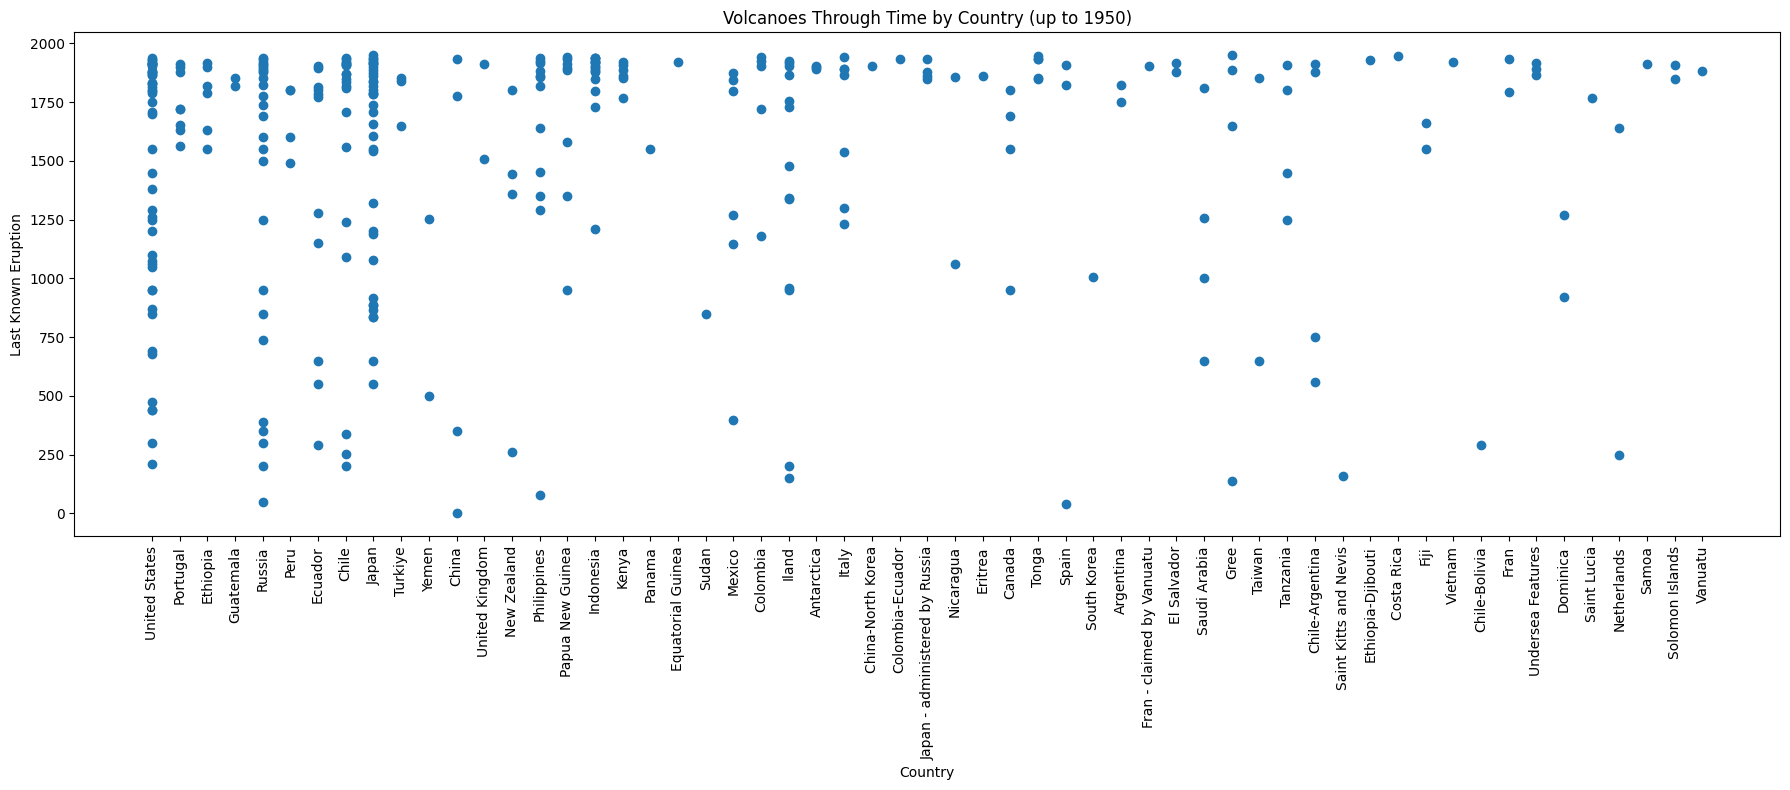

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_excel("VCLocsV2.xlsx")

# Filter for eruptions until 1950
df_filtered = df[df["Last Known Eruption"] <= 1950]

plt.figure(figsize=(18, 8))

# Create scatter plot
scatter = plt.scatter(
    df_filtered["Country"],
    df_filtered["Last Known Eruption"],
)

plt.xlabel("Country")
plt.ylabel("Last Known Eruption")
plt.title("Volcanoes Through Time by Country (up to 1950)")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

####**Figure 2**: Erruptions Per Country in 500-year increments, 0AD to 2000AD (Pie Chart)

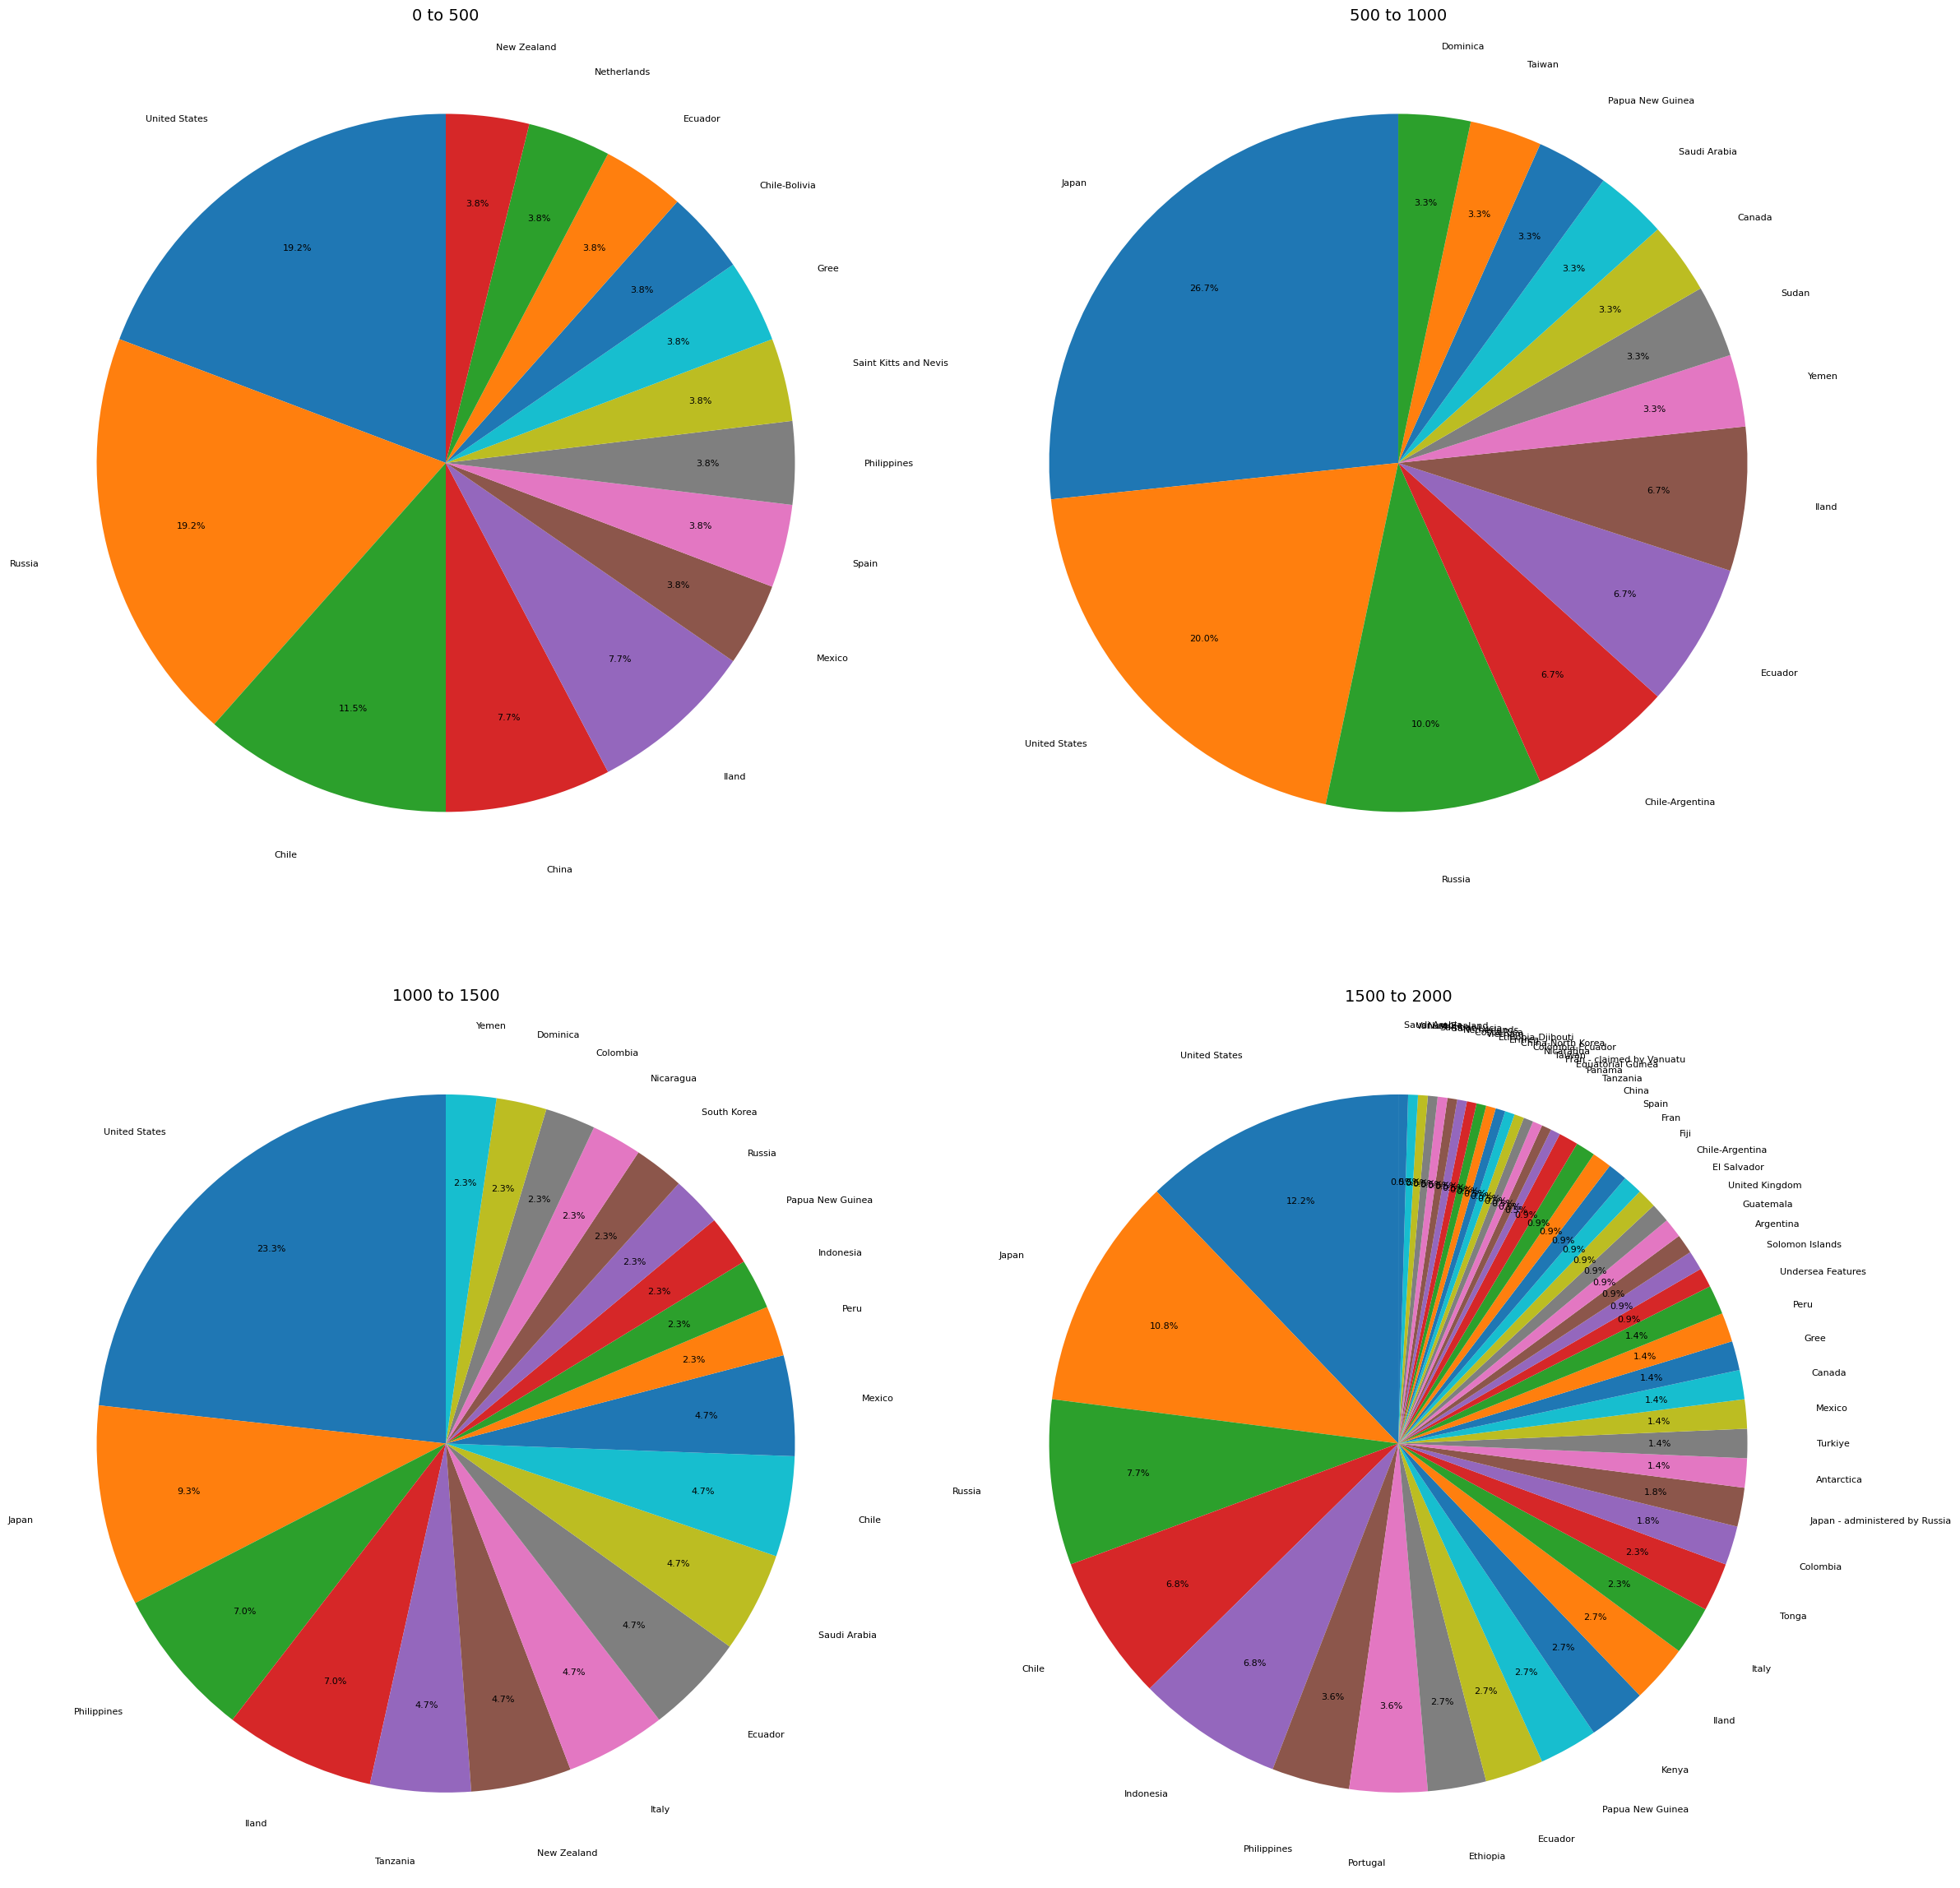

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import math

# Load the data
df = pd.read_excel("VCLocsV2.xlsx")

# Remove missing values
df = df.dropna(subset=["Last Known Eruption", "Country"])

# Keep eruptions up to 1950
df_filtered = df[df["Last Known Eruption"] <= 1950]

# Create 500-year bins
start_year = int(df_filtered["Last Known Eruption"].min() // 500 * 500)
end_year = 2000

bins = list(range(start_year, end_year + 500, 500))
n_bins = len(bins) - 1

# Create subplot grid
cols = 2
rows = math.ceil(n_bins / cols)

fig, axes = plt.subplots(rows, cols, figsize=(24, 12 * rows))
axes = axes.flatten()

# Store wedge information
wedge_data = []

# Create pie charts
for i in range(n_bins):

    start = bins[i]
    end = bins[i + 1]

    subset = df_filtered[
        (df_filtered["Last Known Eruption"] >= start) &
        (df_filtered["Last Known Eruption"] < end)
    ]

    country_counts = subset["Country"].value_counts()

    ax = axes[i]

    if len(country_counts) > 0:

        wedges, texts, autotexts = ax.pie(
            country_counts.values,
            labels=country_counts.index,
            autopct='%1.1f%%',
            startangle=90,
            labeldistance=1.2,
            pctdistance=0.75,
            textprops={'fontsize': 8}
        )

        ax.set_title(f"{start} to {end}", fontsize=14)

        # Store metadata for hovering
        for wedge, country in zip(wedges, country_counts.index):

            eruption_years = subset[
                subset["Country"] == country
            ]["Last Known Eruption"].tolist()

            wedge_data.append({
                "wedge": wedge,
                "country": country,
                "years": eruption_years
            })

    else:
        ax.set_title(f"{start} to {end}\nNo Data")

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Create annotation box
annot = axes[0].annotate(
    "",
    xy=(0, 0),
    xytext=(20, 20),
    textcoords="offset points",
    bbox=dict(boxstyle="round", fc="white", alpha=0.8),
    arrowprops=dict(arrowstyle="->")
)

annot.set_visible(False)


plt.tight_layout()
plt.show()

####**Figure 3**: Number of Erruptions per Country 1500AD to 2000AD (Bar Graph)

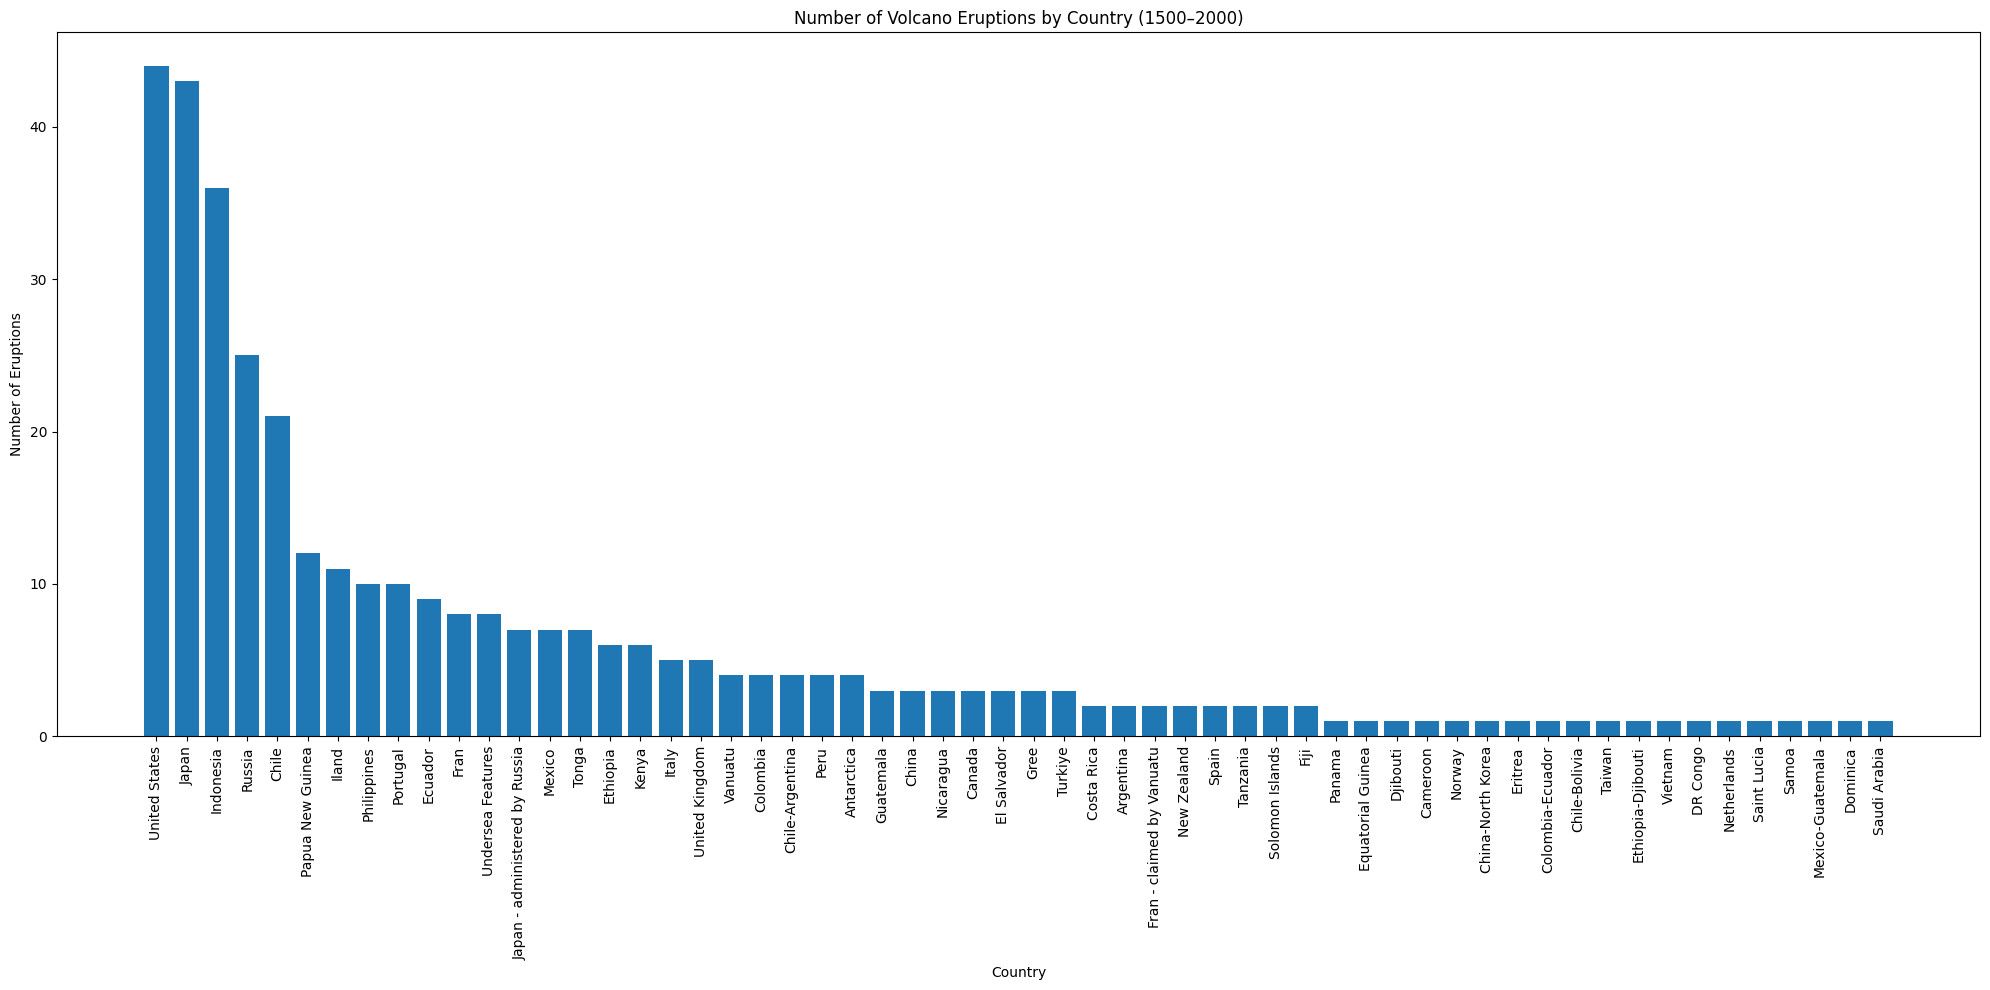

In [8]:
# -----------------------------
# BAR GRAPH: Number of Eruptions by Country (1500–2000)
# -----------------------------

import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_excel("VCLocsV2.xlsx")

# Remove missing values
df = df.dropna(subset=["Last Known Eruption", "Country"])

# Filter years
df_recent = df[
    (df["Last Known Eruption"] >= 1500) &
    (df["Last Known Eruption"] <= 2000)
]

# Count eruptions by country
country_counts = (
    df_recent["Country"]
    .value_counts()
    .sort_values(ascending=False)
)

# Create bar graph
plt.figure(figsize=(20, 10))

plt.bar(
    country_counts.index,
    country_counts.values
)

plt.xlabel("Country")
plt.ylabel("Number of Eruptions")
plt.title("Number of Volcano Eruptions by Country (1500–2000)")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

###**Analysis of Figures 1-3**: Dataset Flaws, Justifications and more

#**Erruption Coding and Analysis**

---




## **Visually Plotting Volcanic Erruptions on Earth** (8300BCE to 2026 AD)

####**Figure 1**: Volcanic Erruptions Across the Globe 8300BCE to 2026 AD

In [ ]:
# Import packages
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

# Read Headings to check columns have the right name. With the amount of changes I made to my dataset throughout this process, this was the easiest way to make sure my code is running the right dataset
df = pd.read_excel("VCLocsV2.xlsx")
print(df.head(0))

Empty DataFrame
Columns: [Volcano Name, Country, Volcano Landform, Primary Volcano Type, Last Known Eruption, Latitude, Longitude, Elevation (m), Dominant Rock Type]
Index: []


In [ ]:
# Constructing Figure 1 for Poster

# ============================================================
# LOAD DATA
# ============================================================

# Load without automatic headers
df = pd.read_excel(
    "VCLocsV2.xlsx",
    header=None
)

# Use first row as headers
df.columns = df.iloc[0]

# Remove header row from data
df = df[1:]

# Clean column names
df.columns = df.columns.str.strip()

# ============================================================
# KEEP REQUIRED COLUMNS
# ============================================================

df = df[[
    "Primary Volcano Type",
    "Latitude",
    "Longitude",
    "Volcano Landform",
    "Elevation (m)",
    "Dominant Rock Type",
    "Last Known Eruption"
]]

# ============================================================
# CLEAN DATA
# ============================================================

# Convert coordinates to numeric
df["Latitude"] = pd.to_numeric(
    df["Latitude"],
    errors="coerce"
)

df["Longitude"] = pd.to_numeric(
    df["Longitude"],
    errors="coerce"
)

# Convert elevation
df["Elevation (m)"] = pd.to_numeric(
    df["Elevation (m)"],
    errors="coerce"
)

# Remove invalid coordinates
df = df.dropna(subset=["Latitude", "Longitude"])

# ============================================================
# COLOUR MAPS
# ============================================================

volcano_types = df["Primary Volcano Type"].unique()

volcano_colours = {
    v: px.colors.qualitative.Dark24[i % 24]
    for i, v in enumerate(volcano_types)
}

# ============================================================
# CREATE FIGURE
# ============================================================

fig = go.Figure()

# ============================================================
# ADD VOLCANOES
# ============================================================

for vtype in volcano_types:

    subset = df[df["Primary Volcano Type"] == vtype]

    fig.add_trace(
        go.Scattergeo(

            lon=subset["Longitude"],
            lat=subset["Latitude"],

            mode="markers",

            marker=dict(
                size=8,
                color=volcano_colours[vtype],
                opacity=0.8
            ),

            # ====================================================
            # HOVER INFORMATION
            # ====================================================

            text=[
                f"""
                <b>Primary Volcano Type:</b> {vt}<br>
                <b>Volcano Landform:</b> {landform}<br>
                <b>Last Known Eruption:</b> {eruption}<br>
                <b>Latitude:</b> {lat}<br>
                <b>Longitude:</b> {lon}<br>
                <b>Elevation (m):</b> {elev}<br>
                <b>Dominant Rock Type:</b> {rock}
                """
                for vt, landform, eruption, lat, lon, elev, rock in zip(
                    subset["Primary Volcano Type"],
                    subset["Volcano Landform"],
                    subset["Last Known Eruption"],
                    subset["Latitude"],
                    subset["Longitude"],
                    subset["Elevation (m)"],
                    subset["Dominant Rock Type"]
                )
            ],

            hoverinfo="text",

            name=vtype
        )
    )

# ============================================================
# LAYOUT
# ============================================================

fig.update_layout(

    title="Global Volcano Erruptions, 8300BCE - 2026 AD (Figure 1)",

    height=850,

    geo=dict(

        projection_type="equirectangular",

        showland=True,
        landcolor="rgb(220,220,220)",

        showocean=True,
        oceancolor="rgb(180,210,255)",

        showcountries=True,
        countrycolor="gray",

        showcoastlines=True,
        coastlinecolor="black",

        showframe=False
    ),

    legend=dict(
        title="Primary Volcano Type"
    )
)

# ============================================================
# SHOW MAP
# ============================================================

fig.show()



---


## **Linearly Plotting Volcanic Erruptions Overtime**: Analysing Correlation


####**Figure 2**: Volcanic Erruptions Per-year 0BCE to 2026 AD

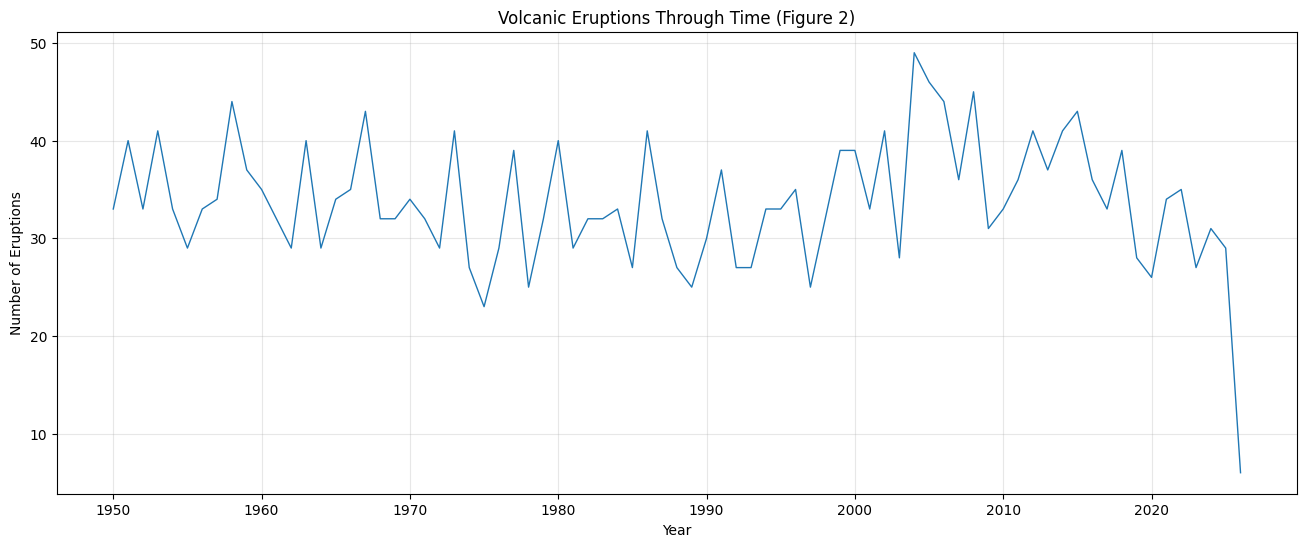

In [ ]:
#First Linear Plot: A general Plot of increase (n) of volcano Erruptions overtime

#Loading/Importing Dataset
df = pd.read_excel("VCErruptionsV2.xlsx")

# Cleaning Data and Converting years into numerical values

def convert_year(value):

    if pd.isna(value):
        return None

    value = str(value).strip()

    if value.lower() == "unknown":
        return None

    # BCE years → negative
    if "BCE" in value:
        num = re.findall(r"\d+", value)
        return -int(num[0]) if num else None

    # CE years → positive
    if "CE" in value:
        num = re.findall(r"\d+", value)
        return int(num[0]) if num else None

    # Plain numeric years
    if value.isdigit():
        return int(value)

    return None

# Apply conversion
df["Year"] = df["Start Year"].apply(convert_year)

# Remove Missing Years. Originally, I had this line to get rid of the volcanoes without years. However, I realised it woudl be better jus tot do this in my original dataset, as that would make it better in general too

#Count Erruptions-per-year to work out total increase overtime per-year

year_counts = (
    df_clean["Year"]
    .value_counts()
    .sort_index()
)

# CREATE FULL TIME SERIES

years = range(
    df_clean["Year"].min(),
    df_clean["Year"].max() + 1
)

counts = [
    year_counts.get(year, 0)
    for year in years
]

# Plotting Figure 2

plt.figure(figsize=(16,6))

plt.plot(
    years,
    counts,
    linewidth=1
)

plt.title("Volcanic Eruptions Through Time (Figure 2)")

plt.xlabel("Year")

plt.ylabel("Number of Eruptions")

plt.grid(alpha=0.3)

plt.show()

####**Figure 3**: Volcanic Erruptions Per-Year 1950-2026

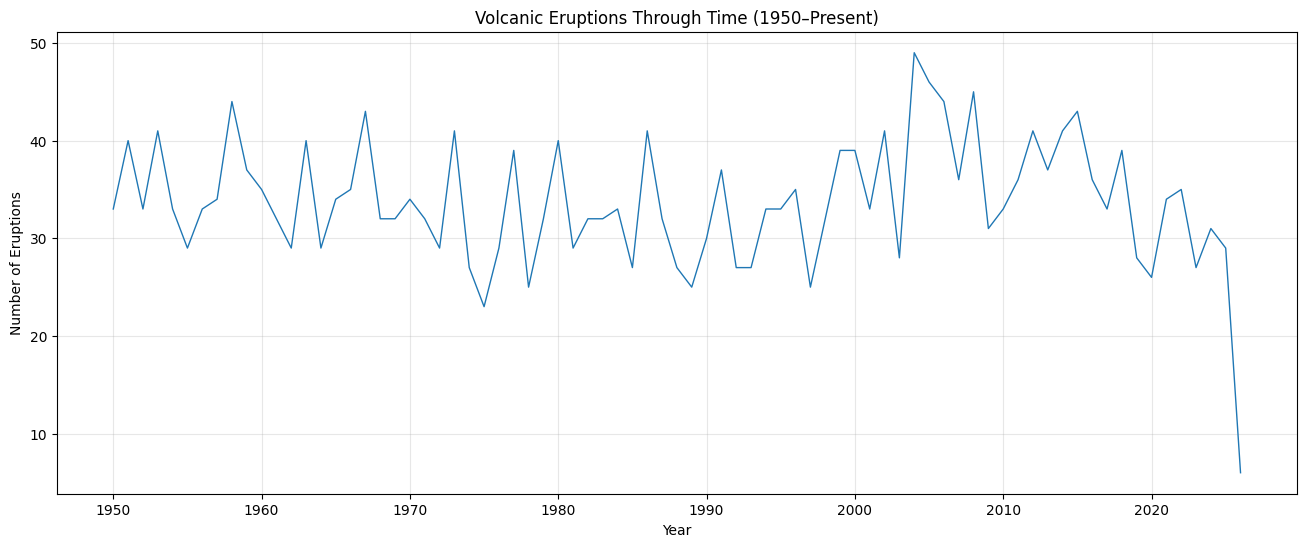

In [ ]:
#Plotting Figure 3: A shortened version of Figure 2, to only include data from 1950-2026

# ============================================================
# LOAD / IMPORT DATASET
# ============================================================

df = pd.read_excel("VCErruptionsV2.xlsx")

# ============================================================
# CLEAN DATA AND CONVERT YEARS
# ============================================================

def convert_year(value):

    if pd.isna(value):
        return None

    value = str(value).strip()

    if value.lower() == "unknown":
        return None

    # BCE years → negative
    if "BCE" in value:
        num = re.findall(r"\d+", value)
        return -int(num[0]) if num else None

    # CE years → positive
    if "CE" in value:
        num = re.findall(r"\d+", value)
        return int(num[0]) if num else None

    # Plain numeric years
    if value.isdigit():
        return int(value)

    return None

# Apply conversion
df["Year"] = df["Start Year"].apply(convert_year)

# ============================================================
# REMOVE MISSING YEARS
# ============================================================

df_clean = df.dropna(subset=["Year"])

# Convert to integer
df_clean["Year"] = df_clean["Year"].astype(int)

# ============================================================
# FILTER YEARS (1950 ONWARDS)
# ============================================================

df_clean = df_clean[df_clean["Year"] >= 1950]

# ============================================================
# COUNT ERUPTIONS PER YEAR
# ============================================================

year_counts = (
    df_clean["Year"]
    .value_counts()
    .sort_index()
)

# ============================================================
# CREATE TIME SERIES
# ============================================================

years = range(
    1950,
    df_clean["Year"].max() + 1
)

counts = [
    year_counts.get(year, 0)
    for year in years
]

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(16,6))

plt.plot(
    years,
    counts,
    linewidth=1
)

plt.title("Volcanic Eruptions Through Time (1950–Present)")

plt.xlabel("Year")

plt.ylabel("Number of Eruptions")

plt.grid(alpha=0.3)

plt.show()

####**Interpreting Figures 2 and 3:** Explaining and Interpreting the Erruption Increase in 2026


The increase in 2026 is not a real spike in volcanic activity but a consequence of how the dataset records ongoing eruptions. For volcanoes that remain active over multiple years, the “Last Known Eruption” field is often updated to the most recent observation year, meaning many long-duration or persistently active volcanoes are assigned the current year (2026 CE). As a result, eruptions that have been occurring or intermittently active over time all get grouped into the same final year rather than being distributed across their actual eruption timeline. This creates an artificial concentration of values in the most recent year and inflates the apparent number of eruptions in 2026, even though it mainly reflects reporting and updating conventions rather than a genuine increase in volcanic activity.

#### Ways we can prevent this from impacting our data

1.  Remove 2026 values entirely if they are being used as a placeholder for ongoing activity rather than a true eruption year, which prevents artificial clustering.
2. Treat these entries separately by distinguishing between historical eruptions and ongoing or recently active volcanoes, rather than combining them in the same dataset.
1.   Improve accuracy by using full eruption histories instead of just the “last known eruption” field
2.   Group data into larger time intervals, such as decades, which reduces noise and smooths out reporting artefacts

####**Figures (4.1, 4.2, 4.3, 4.4 and 4.5)**: Experimenting with Different methods of cleaning data to remove 2026 issues

/tmp/ipykernel_30510/4213035974.py:65: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



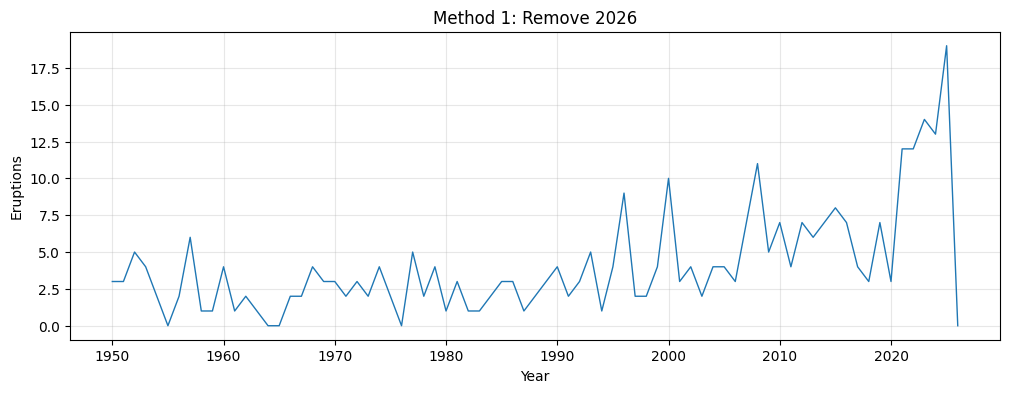

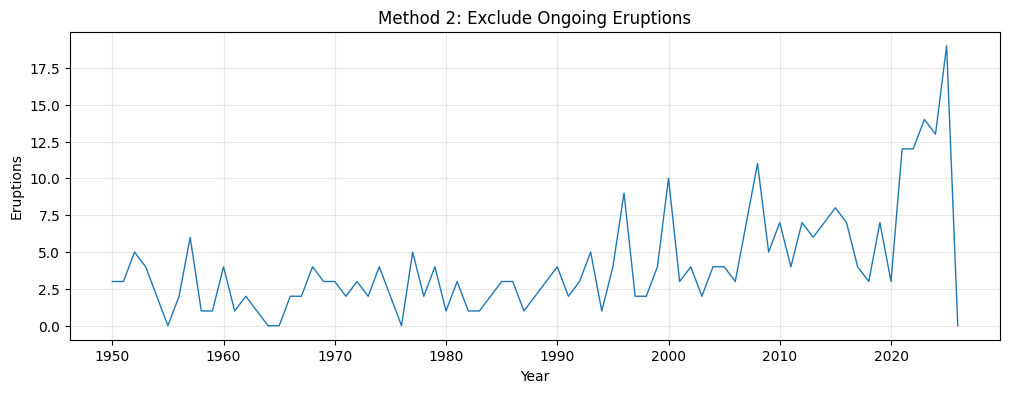

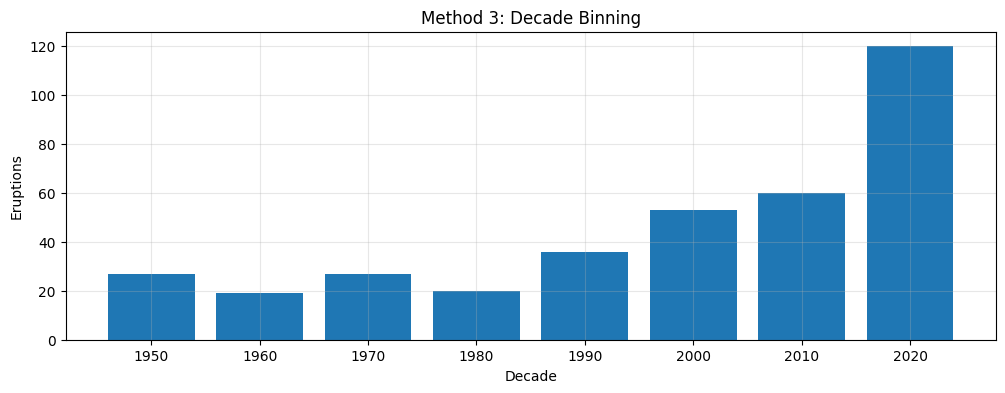

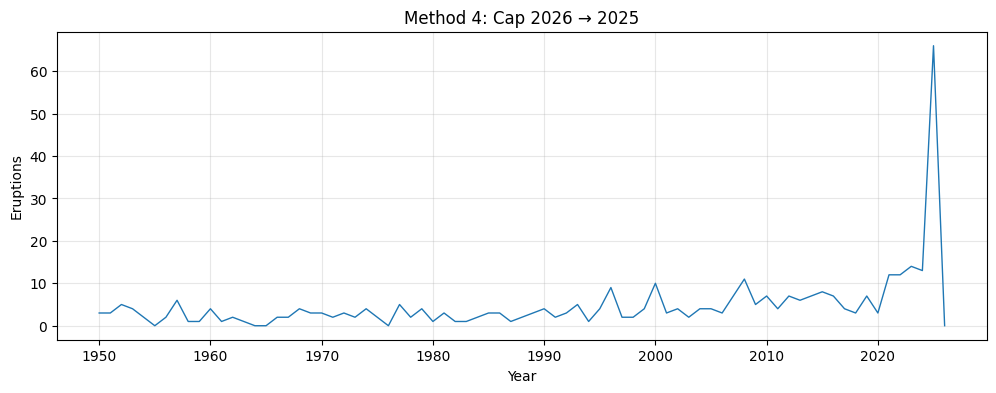

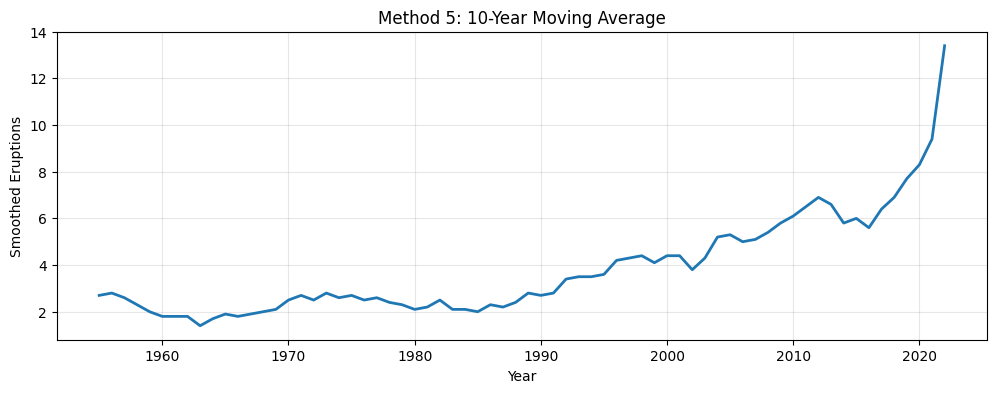

In [ ]:
# ============================================================
# VOLCANIC ERUPTION TIME SERIES ANALYSIS
# ALL DATA FILTERED TO 1950–2026
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import re

# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_excel("VCLocs.xls", header=None)

# Use first row as headers
df.columns = df.iloc[0]

# Remove header row
df = df[1:]

# Clean column names
df.columns = df.columns.str.strip()

# ============================================================
# EXTRACT ERUPTION COLUMN
# ============================================================

y = df["Last Known Eruption"]

# ============================================================
# CLEAN FUNCTION
# ============================================================

def convert_year(value):

    if pd.isna(value):
        return None

    value = str(value).strip()

    if value.lower() == "unknown":
        return None

    # Convert CE years only
    if "CE" in value:

        num = re.findall(r"\d+", value)

        return int(num[0]) if num else None

    # Ignore BCE
    return None

# Apply conversion
df["Year"] = y.apply(convert_year)

# ============================================================
# REMOVE MISSING YEARS
# ============================================================

df_clean = df.dropna(subset=["Year"])

# Convert to integer
df_clean["Year"] = df_clean["Year"].astype(int)

# ============================================================
# FILTER YEARS: 1950–2026 ONLY
# ============================================================

df_clean = df_clean[
    (df_clean["Year"] >= 1950) &
    (df_clean["Year"] <= 2026)
]

# ============================================================
# METHOD 1 — REMOVE 2026
# ============================================================

df_no_2026 = df_clean[
    df_clean["Year"] != 2026
]

# ============================================================
# METHOD 2 — SEPARATE ONGOING
# ============================================================

df_ongoing = df_clean[
    df_clean["Year"] == 2026
]

df_historical = df_clean[
    df_clean["Year"] != 2026
]

# ============================================================
# METHOD 3 — DECADE BINNING
# ============================================================

df_decade = df_clean.copy()

df_decade["Decade"] = (
    df_decade["Year"] // 10
) * 10

decade_counts = (
    df_decade["Decade"]
    .value_counts()
    .sort_index()
)

# ============================================================
# METHOD 4 — CAP 2026 → 2025
# ============================================================

df_capped = df_clean.copy()

df_capped["Year"] = (
    df_capped["Year"]
    .replace(2026, 2025)
)

# ============================================================
# METHOD 5 — MOVING AVERAGE
# ============================================================

year_counts_raw = (
    df_clean["Year"]
    .value_counts()
    .sort_index()
)

years = range(1950, 2027)

counts_raw = [
    year_counts_raw.get(y, 0)
    for y in years
]

rolling_avg = (
    pd.Series(counts_raw)
    .rolling(window=10, center=True)
    .mean()
)

# ============================================================
# PLOTTING FUNCTION
# ============================================================

def plot_data(title, years, counts):

    plt.figure(figsize=(12,4))

    plt.plot(
        years,
        counts,
        linewidth=1
    )

    plt.title(title)

    plt.xlabel("Year")

    plt.ylabel("Eruptions")

    plt.grid(alpha=0.3)

    plt.show()

# ============================================================
# METHOD 1 — REMOVE 2026
# ============================================================

counts1 = (
    df_no_2026["Year"]
    .value_counts()
    .sort_index()
)

plot_data(
    "Method 1: Remove 2026",
    years,
    [counts1.get(y, 0) for y in years]
)

# ============================================================
# METHOD 2 — EXCLUDE ONGOING
# ============================================================

counts2 = (
    df_historical["Year"]
    .value_counts()
    .sort_index()
)

plot_data(
    "Method 2: Exclude Ongoing Eruptions",
    years,
    [counts2.get(y, 0) for y in years]
)

# ============================================================
# METHOD 3 — DECADE BINNING
# ============================================================

plt.figure(figsize=(12,4))

plt.bar(
    decade_counts.index,
    decade_counts.values,
    width=8
)

plt.title("Method 3: Decade Binning")

plt.xlabel("Decade")

plt.ylabel("Eruptions")

plt.grid(alpha=0.3)

plt.show()

# ============================================================
# METHOD 4 — CAP 2026 → 2025
# ============================================================

counts4 = (
    df_capped["Year"]
    .value_counts()
    .sort_index()
)

plot_data(
    "Method 4: Cap 2026 → 2025",
    years,
    [counts4.get(y, 0) for y in years]
)

# ============================================================
# METHOD 5 — MOVING AVERAGE
# ============================================================

plt.figure(figsize=(12,4))

plt.plot(
    years,
    rolling_avg,
    linewidth=2
)

plt.title("Method 5: 10-Year Moving Average")

plt.xlabel("Year")

plt.ylabel("Smoothed Eruptions")

plt.grid(alpha=0.3)

plt.show()

####**Interpreting Figures (4.1, 4.2, 4.3, 4.4 and 4.5)**

####**Figure 5.1**: Plotting Regression of Volcanic Erruptions Per Year (1950-2026)
**Time Series Analysis (Week 10)**
Time series analysis will be used to study how volcanic eruptions change through time. Eruptions will be counted by year and plotted on line graphs to identify patterns in eruption frequency. Moving averages and rolling means will be used to smooth the data and highlight periods of high or low activity. The results will then be analysed to determine whether eruptions occur randomly or  in temporal clusters.

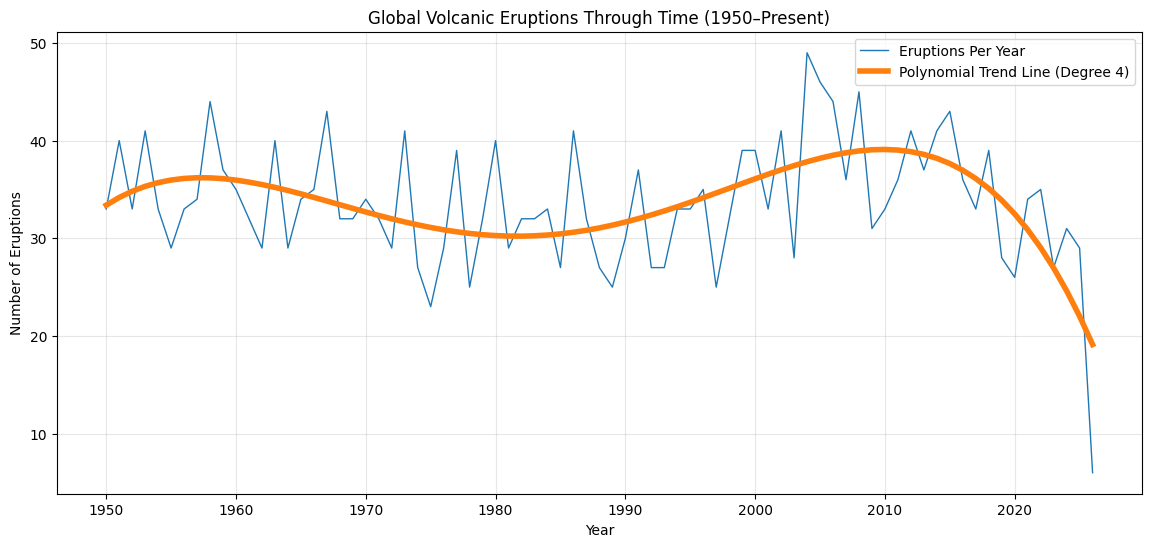

In [ ]:
#add uncertainty

# ============================================================
# TIME SERIES ANALYSIS OF GLOBAL VOLCANIC ERUPTIONS
# WITH IMPROVED TREND LINE
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_excel("VCErrupt1950.xlsx")

# ============================================================
# CLEAN / CONVERT YEARS
# ============================================================

def convert_year(value):

    if pd.isna(value):
        return None

    value = str(value).strip()

    if value.lower() == "unknown":
        return None

    # BCE years
    if "BCE" in value:
        num = re.findall(r"\d+", value)
        return -int(num[0]) if num else None

    # CE years
    if "CE" in value:
        num = re.findall(r"\d+", value)
        return int(num[0]) if num else None

    # Plain numeric years
    if value.isdigit():
        return int(value)

    return None

# Apply conversion
df["Year"] = df["Start Year"].apply(convert_year)

# Remove missing years
df_clean = df.dropna(subset=["Year"])

# Convert to integer
df_clean["Year"] = df_clean["Year"].astype(int)

# ============================================================
# FILTER YEARS (1950 ONWARDS)
# ============================================================

df_clean = df_clean[df_clean["Year"] >= 1950]

# ============================================================
# COUNT ERUPTIONS PER YEAR
# ============================================================

eruption_counts = (
    df_clean["Year"]
    .value_counts()
    .sort_index()
)

# ============================================================
# CREATE COMPLETE TIME SERIES
# ============================================================

all_years = np.arange(
    1950,
    df_clean["Year"].max() + 1
)

all_counts = np.array([
    eruption_counts.get(year, 0)
    for year in all_years
])

# ============================================================
# CREATE DATAFRAME
# ============================================================

time_series = pd.DataFrame({
    "Year": all_years,
    "Eruptions": all_counts
})

# ============================================================
# POLYNOMIAL TREND LINE
# ============================================================

# Lower degree avoids extreme overfitting
degree = 4

z = np.polyfit(
    time_series["Year"],
    time_series["Eruptions"],
    degree
)

p = np.poly1d(z)

trendline = p(time_series["Year"])

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(14,6))

# Raw eruption counts
plt.plot(
    time_series["Year"],
    time_series["Eruptions"],
    linewidth=1,
    label="Eruptions Per Year"
)

# Trend line
plt.plot(
    time_series["Year"],
    trendline,
    linewidth=4,
    label=f"Polynomial Trend Line (Degree {degree})"
)

# Labels
plt.xlabel("Year")

plt.ylabel("Number of Eruptions")

plt.title(
    "Global Volcanic Eruptions Through Time (1950–Present)"
)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

####**Figure 5.2**: Plotting Regression of Volcanic Erruptions Per Year. Finding best polynomial fit (1950-2026)


In [ ]:
!pip install bambi pymc arviz

Fitting 0-order model...


Output()

/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning:

Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.



Fitting 1st-order model...


Output()

...

/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning:

Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.



Fitting 4th-order model...


Output()

/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning:

Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.

/usr/local/lib/python3.12/dist-packages/arviz_stats/loo/helper_loo.py:1146: UserWarning:

Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.

/usr/local/lib/python3.12/dist-packages/arviz_stats/loo/helper_loo.py:1146: UserWarning:

Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal post


MODEL COMPARISON
           rank   elpd    p  elpd_diff  weight    se  dse  warning
4th-order     0 -240.0  6.6        0.0    0.96   6.0  0.0     True
3rd-order     1 -250.0  6.1       -7.0    0.00   8.0  4.1    False
0-order       2 -260.0  3.6      -10.0    0.04  11.0  7.1     True
1st-order     3 -260.0  4.3      -10.0    0.00  11.0  6.8     True
2nd-order     4 -260.0  5.7      -10.0    0.00  11.0  6.9     True

Best model:
4th-order


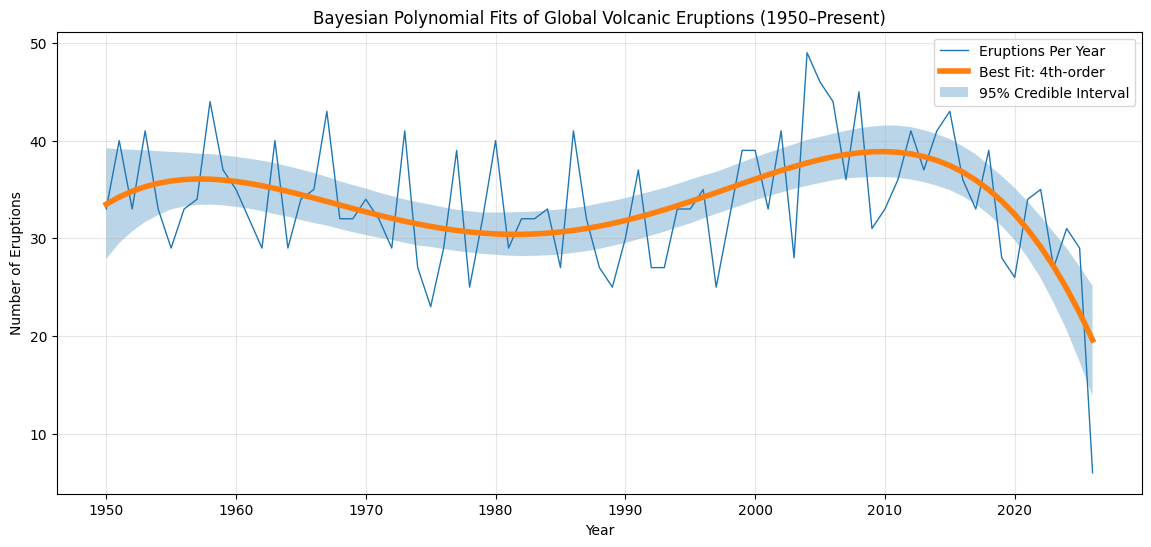

In [ ]:
# ============================================================
# BAYESIAN POLYNOMIAL MODEL COMPARISON
# GLOBAL VOLCANIC ERUPTIONS THROUGH TIME
# ============================================================

# ============================================================
# INSTALL PACKAGES (RUN ONCE)
# ============================================================

# !pip install bambi pymc arviz openpyxl

# ============================================================
# IMPORTS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

import bambi as bmb
import arviz as az

# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_excel("VCErrupt1950.xlsx")

# ============================================================
# CLEAN / CONVERT YEARS
# ============================================================

def convert_year(value):

    if pd.isna(value):
        return None

    value = str(value).strip()

    if value.lower() == "unknown":
        return None

    # BCE years
    if "BCE" in value:
        num = re.findall(r"\d+", value)
        return -int(num[0]) if num else None

    # CE years
    if "CE" in value:
        num = re.findall(r"\d+", value)
        return int(num[0]) if num else None

    # Plain numeric years
    if value.isdigit():
        return int(value)

    return None

# Apply conversion
df["Year"] = df["Start Year"].apply(convert_year)

# Remove missing years
df_clean = df.dropna(subset=["Year"]).copy()

# Convert to integer
df_clean["Year"] = df_clean["Year"].astype(int)

# ============================================================
# FILTER YEARS (1950 ONWARDS)
# ============================================================

df_clean = df_clean[df_clean["Year"] >= 1950]

# ============================================================
# COUNT ERUPTIONS PER YEAR
# ============================================================

eruption_counts = (
    df_clean["Year"]
    .value_counts()
    .sort_index()
)

# ============================================================
# CREATE COMPLETE TIME SERIES
# ============================================================

all_years = np.arange(
    1950,
    df_clean["Year"].max() + 1
)

all_counts = np.array([
    eruption_counts.get(year, 0)
    for year in all_years
])

# ============================================================
# CREATE DATAFRAME
# ============================================================

time_series = pd.DataFrame({
    "Year": all_years,
    "Eruptions": all_counts
})

# ============================================================
# SCALE YEARS
# IMPORTANT FOR POLYNOMIAL STABILITY
# ============================================================

time_series["x"] = (
    time_series["Year"] - time_series["Year"].mean()
) / time_series["Year"].std()

# Polynomial terms
time_series["x2"] = time_series["x"]**2
time_series["x3"] = time_series["x"]**3
time_series["x4"] = time_series["x"]**4

# ============================================================
# FIT MODELS
# ============================================================

print("Fitting 0-order model...")

model0 = bmb.Model(
    "Eruptions ~ 1",
    time_series
)

idata0 = model0.fit(
    draws=1000,
    tune=1000,
    target_accept=0.95,
    idata_kwargs={"log_likelihood": True}
)

# ------------------------------------------------------------

print("Fitting 1st-order model...")

model1 = bmb.Model(
    "Eruptions ~ x",
    time_series
)

idata1 = model1.fit(
    draws=1000,
    tune=1000,
    target_accept=0.95,
    idata_kwargs={"log_likelihood": True}
)

# ------------------------------------------------------------

print("Fitting 2nd-order model...")

model2 = bmb.Model(
    "Eruptions ~ x + x2",
    time_series
)

idata2 = model2.fit(
    draws=1000,
    tune=1000,
    target_accept=0.95,
    idata_kwargs={"log_likelihood": True}
)

# ------------------------------------------------------------

print("Fitting 3rd-order model...")

model3 = bmb.Model(
    "Eruptions ~ x + x2 + x3",
    time_series
)

idata3 = model3.fit(
    draws=1000,
    tune=1000,
    target_accept=0.95,
    idata_kwargs={"log_likelihood": True}
)

# ------------------------------------------------------------

print("Fitting 4th-order model...")

model4 = bmb.Model(
    "Eruptions ~ x + x2 + x3 + x4",
    time_series
)

idata4 = model4.fit(
    draws=1000,
    tune=1000,
    target_accept=0.95,
    idata_kwargs={"log_likelihood": True}
)

# ============================================================
# MODEL COMPARISON
# ============================================================

comparison = az.compare(
    {
        "0-order": idata0,
        "1st-order": idata1,
        "2nd-order": idata2,
        "3rd-order": idata3,
        "4th-order": idata4
    }
)

print("\n================================================")
print("MODEL COMPARISON")
print("================================================")

print(comparison)

# ============================================================
# SELECT BEST MODEL
# ============================================================

best_model_name = comparison.index[0]

print("\nBest model:")
print(best_model_name)

# ============================================================
# CHOOSE BEST MODEL
# ============================================================

if best_model_name == "0-order":
    model_best = model0
    idata_best = idata0

elif best_model_name == "1st-order":
    model_best = model1
    idata_best = idata1

elif best_model_name == "2nd-order":
    model_best = model2
    idata_best = idata2

elif best_model_name == "3rd-order":
    model_best = model3
    idata_best = idata3

else:
    model_best = model4
    idata_best = idata4

# ============================================================
# GENERATE POSTERIOR PREDICTIONS
# ============================================================

predictions = model_best.predict(
    idata_best,
    kind="mean",
    inplace=False
)

# Extract posterior predictions
posterior = predictions.posterior["mu"].values

# Mean prediction
mean_pred = posterior.mean(axis=(0, 1))

# 95% credible interval
lower = np.percentile(
    posterior,
    2.5,
    axis=(0, 1)
)

upper = np.percentile(
    posterior,
    97.5,
    axis=(0, 1)
)

# ============================================================
# PLOT RESULTS
# ============================================================

plt.figure(figsize=(14, 6))

# Raw eruption counts
plt.plot(
    time_series["Year"],
    time_series["Eruptions"],
    linewidth=1,
    label="Eruptions Per Year"
)

# Bayesian fit
plt.plot(
    time_series["Year"],
    mean_pred,
    linewidth=4,
    label=f"Best Fit: {best_model_name}"
)

# Uncertainty interval
plt.fill_between(
    time_series["Year"],
    lower,
    upper,
    alpha=0.3,
    label="95% Credible Interval"
)

# Labels
plt.xlabel("Year")
plt.ylabel("Number of Eruptions")

plt.title(
    "Bayesian Polynomial Fits of Global Volcanic Eruptions (1950–Present)"
)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

####**Interpeting Figure 5**

####**Figure 6**: Plotting Regression of Volcanic Erruptions Per Year (1950-2026)


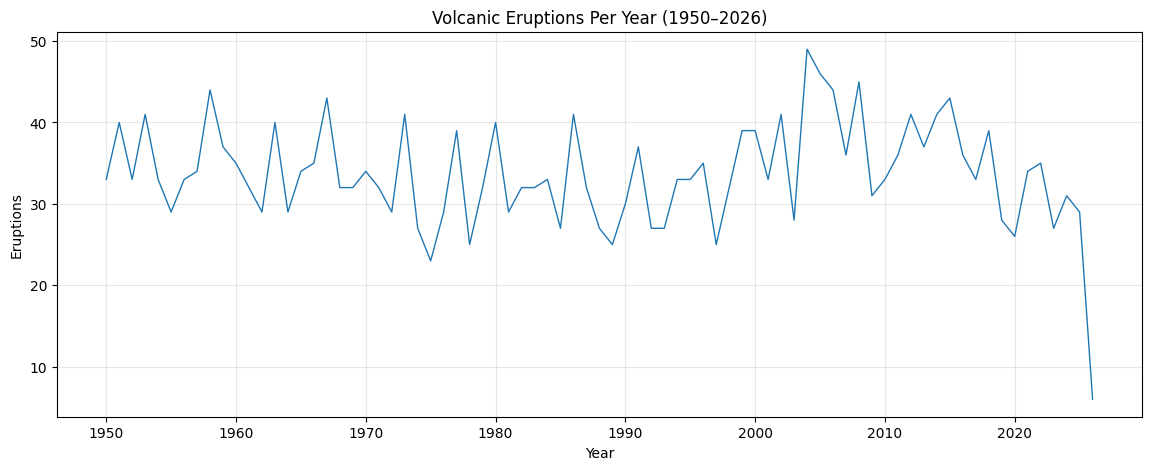

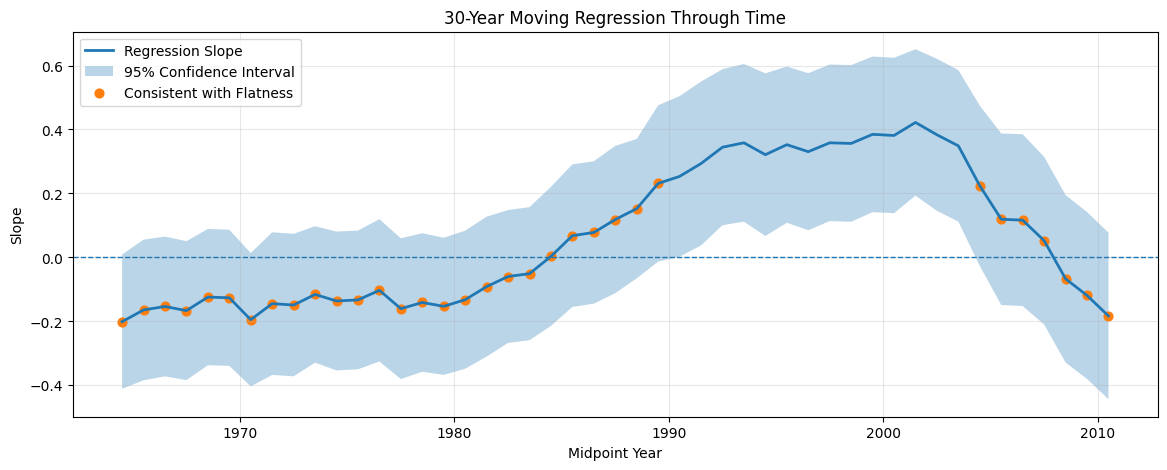

Flat behaviour begins approximately around 1964.


In [ ]:
# ============================================================
# 0TH vs 1ST ORDER MODEL TEST
# MOVING 30-YEAR REGRESSION
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
from scipy.stats import linregress

# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_excel("VCErruptionsV2.xlsx")

# ============================================================
# CLEAN YEARS
# ============================================================

def convert_year(value):

    if pd.isna(value):
        return None

    value = str(value).strip()

    if value.lower() == "unknown":
        return None

    if "CE" in value:
        num = re.findall(r"\d+", value)
        return int(num[0]) if num else None

    if value.isdigit():
        return int(value)

    return None

df["Year"] = df["Start Year"].apply(convert_year)

# ============================================================
# CLEAN DATA
# ============================================================

df_clean = df.dropna(subset=["Year"])

df_clean["Year"] = df_clean["Year"].astype(int)

df_clean = df_clean[
    (df_clean["Year"] >= 1950) &
    (df_clean["Year"] <= 2026)
]

# ============================================================
# COUNT ERUPTIONS PER YEAR
# ============================================================

year_counts = (
    df_clean["Year"]
    .value_counts()
    .sort_index()
)

years = np.arange(1950, 2027)

counts = np.array([
    year_counts.get(y, 0)
    for y in years
])

# ============================================================
# MOVING 30-YEAR REGRESSION
# ============================================================

window = 30

mid_years = []

slopes = []
slope_errors = []

flat_flags = []

for start in range(len(years) - window):

    x = years[start:start + window]
    y = counts[start:start + window]

    result = linregress(x, y)

    slope = result.slope
    stderr = result.stderr

    mid_year = x.mean()

    mid_years.append(mid_year)

    slopes.append(slope)

    slope_errors.append(stderr)

    # ========================================================
    # TEST IF SLOPE CONSISTENT WITH ZERO
    # ========================================================

    lower = slope - 2 * stderr
    upper = slope + 2 * stderr

    # If 95% interval overlaps 0:
    flat = (lower <= 0 <= upper)

    flat_flags.append(flat)

# ============================================================
# PLOT 1 — ERUPTIONS THROUGH TIME
# ============================================================

plt.figure(figsize=(14,5))

plt.plot(
    years,
    counts,
    linewidth=1
)

plt.title(
    "Volcanic Eruptions Per Year (1950–2026)"
)

plt.xlabel("Year")

plt.ylabel("Eruptions")

plt.grid(alpha=0.3)

plt.show()

# ============================================================
# PLOT 2 — MOVING SLOPE ANALYSIS
# ============================================================

plt.figure(figsize=(14,5))

# slope
plt.plot(
    mid_years,
    slopes,
    linewidth=2,
    label="Regression Slope"
)

# uncertainty band
slopes = np.array(slopes)
slope_errors = np.array(slope_errors)

plt.fill_between(
    mid_years,
    slopes - 2*slope_errors,
    slopes + 2*slope_errors,
    alpha=0.3,
    label="95% Confidence Interval"
)

# zero line
plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

# highlight flat regions
flat_x = [
    x for x, f in zip(mid_years, flat_flags)
    if f
]

flat_y = [
    y for y, f in zip(slopes, flat_flags)
    if f
]

plt.scatter(
    flat_x,
    flat_y,
    s=40,
    label="Consistent with Flatness"
)

plt.title(
    "30-Year Moving Regression Through Time"
)

plt.xlabel("Midpoint Year")

plt.ylabel("Slope")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

# ============================================================
# PRINT FLAT INTERVALS
# ============================================================

if any(flat_flags):

    first_flat = flat_x[0]

    print(
        f"Flat behaviour begins approximately around {first_flat:.0f}."
    )

else:

    print(
        "No interval statistically consistent with flatness."
    )

**Interpreting Figure 6**


####**Figure 7:** Determining Randomness using Monte Carlo

Observed Variance: 35.626243885984145
Mean Simulated Variance: 4.606823106763367
Monte Carlo p-value: 0.0


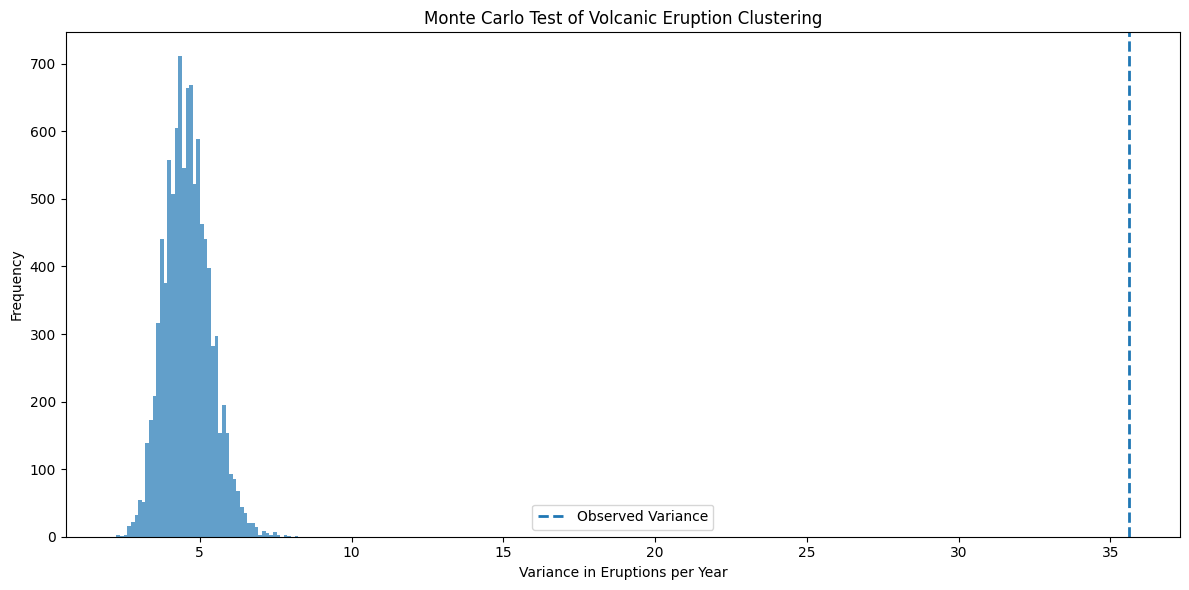

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# LOAD DATA
# -----------------------------

df = pd.read_excel("VCLocsV2.xlsx")

# Remove missing eruption years
df = df.dropna(subset=["Last Known Eruption"])

# Convert to integers
eruption_years = df["Last Known Eruption"].astype(int)

# Focus on 1950–2026
eruption_years = eruption_years[
    (eruption_years >= 1950) &
    (eruption_years <= 2026)
]

# -----------------------------
# OBSERVED DATA
# -----------------------------

# Count eruptions per year
observed_counts = eruption_years.value_counts().sort_index()

years = np.arange(1950, 2027)

# Ensure every year exists
observed_series = pd.Series(0, index=years)

for year, count in observed_counts.items():
    observed_series[year] = count

# -----------------------------
# CLUSTERING METRIC
# -----------------------------

# Use variance as a measure of clustering
# Higher variance = more clustering

observed_variance = np.var(observed_series)

# -----------------------------
# MONTE CARLO SIMULATION
# -----------------------------

n_simulations = 10000

simulated_variances = []

total_eruptions = len(eruption_years)

for i in range(n_simulations):

    # Randomly assign eruption years
    simulated_years = np.random.choice(
        years,
        size=total_eruptions,
        replace=True
    )

    # Count eruptions per year
    simulated_counts = pd.Series(simulated_years).value_counts()

    simulated_series = pd.Series(0, index=years)

    for year, count in simulated_counts.items():
        simulated_series[year] = count

    # Store variance
    simulated_variances.append(
        np.var(simulated_series)
    )

# -----------------------------
# P-VALUE
# -----------------------------

simulated_variances = np.array(simulated_variances)

p_value = np.mean(
    simulated_variances >= observed_variance
)

# -----------------------------
# RESULTS
# -----------------------------

print("Observed Variance:", observed_variance)
print("Mean Simulated Variance:", simulated_variances.mean())
print("Monte Carlo p-value:", p_value)

# -----------------------------
# PLOT RESULTS
# -----------------------------

plt.figure(figsize=(12, 6))

plt.hist(
    simulated_variances,
    bins=50,
    alpha=0.7
)

plt.axvline(
    observed_variance,
    linestyle='--',
    linewidth=2,
    label='Observed Variance'
)

plt.xlabel("Variance in Eruptions per Year")
plt.ylabel("Frequency")
plt.title("Monte Carlo Test of Volcanic Eruption Clustering")

plt.legend()

plt.tight_layout()
plt.show()

**Interpeting Figure 7:** Randomness, Correlation

The Monte Carlo simulation shows strong evidence that volcanic eruptions between 1950–2026 are not randomly distributed through time. The observed variance in eruptions per year was 35.63, while the average variance produced by the random simulations was only 4.61. Variance measures how unevenly eruptions are distributed across years, so the much larger observed variance indicates that real eruptions are far more clustered than would be expected if eruptions occurred purely by chance. The Monte Carlo p-value of 0.0 means that none of the 10,000 simulated random datasets produced a variance equal to or greater than the real eruption record, providing extremely strong statistical evidence against randomness. This suggests that volcanic eruptions tend to occur in temporal clusters, where periods of elevated volcanic activity are followed by quieter periods rather than eruptions being evenly distributed through time.

The code works by first loading the eruption dataset and filtering eruption years between 1950 and 2026. It then counts the number of eruptions occurring in each year and calculates the variance of these yearly counts, which acts as the clustering metric. A Monte Carlo simulation is then performed 10,000 times by randomly redistributing the same total number of eruptions across the available years while preserving the total eruption count. For each simulation, yearly eruption counts and their variance are recalculated. These simulated variances form a probability distribution representing what eruption variability would look like if eruptions occurred randomly. Finally, the observed variance is compared to the simulated distribution to calculate the p-value, showing how likely the observed clustering would be under a random process.

####**Figure 8:**

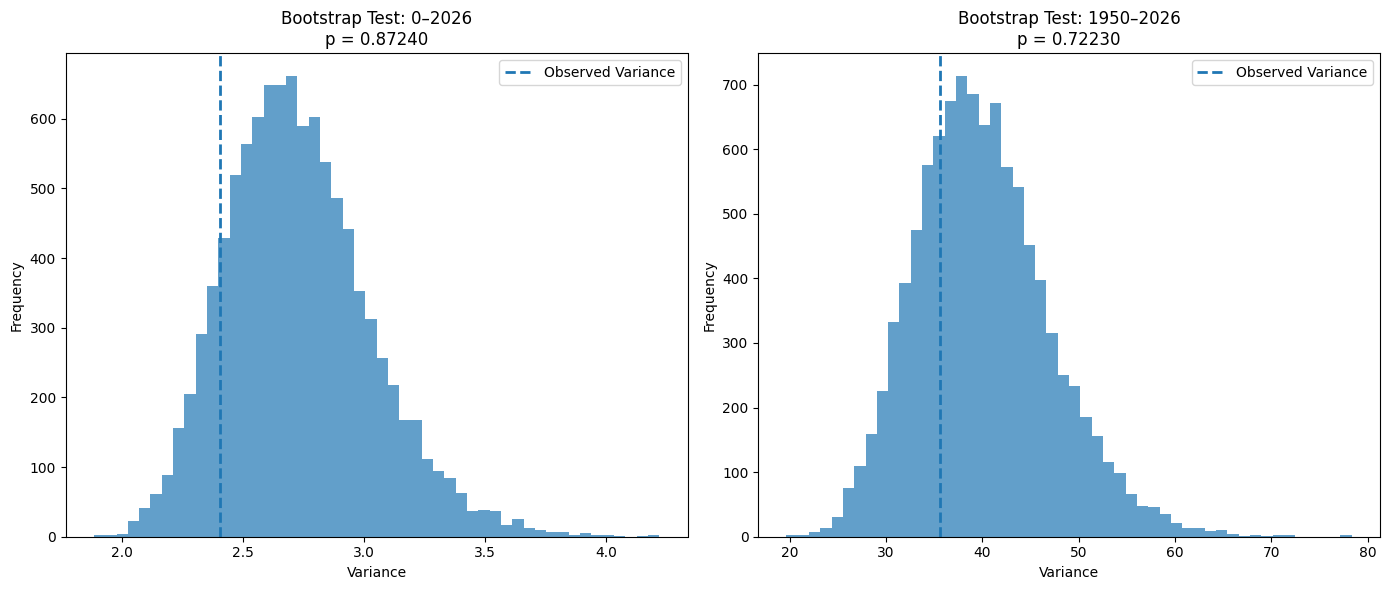

0–2026
Observed Variance: 2.4021803336262857
Bootstrap Mean Variance: 2.7282995245488326
p-value: 0.8724

1950–2026
Observed Variance: 35.626243885984145
Bootstrap Mean Variance: 40.02126726260752
p-value: 0.7223


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# LOAD DATA
# -----------------------------

df = pd.read_excel("VCLocsV2.xlsx")

# Remove missing eruption years
df = df.dropna(subset=["Last Known Eruption"])

# Convert to integers
df["Last Known Eruption"] = (
    df["Last Known Eruption"].astype(int)
)

# -----------------------------
# FUNCTION
# -----------------------------

def bootstrap_randomness_test(start_year, end_year, n_bootstrap=10000):

    # Filter years
    eruption_years = df[
        (df["Last Known Eruption"] >= start_year) &
        (df["Last Known Eruption"] <= end_year)
    ]["Last Known Eruption"]

    years = np.arange(start_year, end_year + 1)

    # Observed yearly counts
    observed_counts = eruption_years.value_counts()

    observed_series = pd.Series(0, index=years)

    for year, count in observed_counts.items():
        observed_series[year] = count

    # Observed variance
    observed_variance = np.var(observed_series)

    # -----------------------------
    # BOOTSTRAPPING
    # -----------------------------

    bootstrap_variances = []

    for i in range(n_bootstrap):

        # Resample eruption years WITH replacement
        bootstrap_sample = np.random.choice(
            eruption_years,
            size=len(eruption_years),
            replace=True
        )

        # Count eruptions per year
        bootstrap_counts = (
            pd.Series(bootstrap_sample)
            .value_counts()
        )

        bootstrap_series = pd.Series(0, index=years)

        for year, count in bootstrap_counts.items():
            bootstrap_series[year] = count

        # Store variance
        bootstrap_variances.append(
            np.var(bootstrap_series)
        )

    bootstrap_variances = np.array(
        bootstrap_variances
    )

    # p-value
    p_value = np.mean(
        bootstrap_variances >= observed_variance
    )

    return (
        observed_variance,
        bootstrap_variances,
        p_value
    )

# -----------------------------
# RUN TESTS
# -----------------------------

obs1, boot1, p1 = bootstrap_randomness_test(
    0,
    2026
)

obs2, boot2, p2 = bootstrap_randomness_test(
    1950,
    2026
)

# -----------------------------
# PLOTS
# -----------------------------

plt.figure(figsize=(14, 6))

# 0–2026
plt.subplot(1, 2, 1)

plt.hist(
    boot1,
    bins=50,
    alpha=0.7
)

plt.axvline(
    obs1,
    linestyle='--',
    linewidth=2,
    label='Observed Variance'
)

plt.xlabel("Variance")
plt.ylabel("Frequency")
plt.title(f"Bootstrap Test: 0–2026\np = {p1:.5f}")

plt.legend()

# 1950–2026
plt.subplot(1, 2, 2)

plt.hist(
    boot2,
    bins=50,
    alpha=0.7
)

plt.axvline(
    obs2,
    linestyle='--',
    linewidth=2,
    label='Observed Variance'
)

plt.xlabel("Variance")
plt.ylabel("Frequency")
plt.title(f"Bootstrap Test: 1950–2026\np = {p2:.5f}")

plt.legend()

plt.tight_layout()
plt.show()

# -----------------------------
# PRINT RESULTS
# -----------------------------

print("0–2026")
print("Observed Variance:", obs1)
print("Bootstrap Mean Variance:", boot1.mean())
print("p-value:", p1)

print("\n1950–2026")
print("Observed Variance:", obs2)
print("Bootstrap Mean Variance:", boot2.mean())
print("p-value:", p2)

**Interpeting Figure 8:** Clustering?

The bootstrap results suggest that the eruption record does not show statistically significant temporal clustering relative to the structure already present in the observed data. For the full 0–2026 dataset, the observed variance was 2.40, while the bootstrap mean variance was slightly higher at 2.73, with a p-value of 0.8724. This means that around 87% of the bootstrap simulations produced variance values greater than or equal to the observed variance, indicating that the real eruption pattern is highly consistent with the resampled datasets and therefore does not significantly differ from randomness under this bootstrap framework. Similarly, for the 1950–2026 dataset, the observed variance was 35.63 compared to a bootstrap mean variance of 40.02, with a p-value of 0.7223, again showing that the observed clustering is not unusually large compared to the bootstrap distribution. Unlike the Monte Carlo randomisation test, which redistributed eruptions uniformly across all years and found strong evidence for clustering, the bootstrap approach resampled directly from the observed eruption years themselves. This preserves the existing temporal structure within the data, meaning the bootstrap test is measuring the stability and reproducibility of the observed pattern rather than testing against complete randomness. As a result, the bootstrap analysis suggests that the clustering observed in the eruption record is internally consistent and reproducible, but not statistically extreme relative to the existing eruption distribution.

The results suggest that volcanic eruptions are not completely random through time and likely show real temporal clustering, especially from 1950–2026. The Monte Carlo test found that eruptions cluster far more than expected from pure chance, implying that periods of heightened volcanic activity occur globally. Real-world explanations could include tectonic plate interactions triggering multiple volcanic systems, stress transfer between nearby volcanoes, large-scale mantle processes, or improvements in modern monitoring that detect more eruptions in recent decades.

The bootstrap test produced high p-values because it resampled from the existing eruption record, meaning it preserved the clustering already present in the data. This shows that the observed eruption pattern is stable and reproducible rather than anomalous. Overall, the strongest statistical evidence comes from the Monte Carlo analysis, which supports the conclusion that volcanic eruptions are temporally correlated rather than purely random.

#**Erruption Final Analysis and Reflection**
---

##**Final Analysis**



##**Reflection**


